# Importando os dados

In [ ]:
# Importação das principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Leitura dos dados
df_ibov = pd.read_csv('Dados Históricos - Ibovespa.csv', sep=',')
df_ibov.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,27.01.2026,182.709,178.852,183.041,178.852,"3,76M","2,23%"
1,26.01.2026,178.721,178.859,179.543,177.694,"9,57B","-0,08%"
2,23.01.2026,178.859,175.590,180.532,175.590,"11,78B","1,86%"
3,22.01.2026,175.589,171.817,177.742,171.817,"14,02B","2,20%"
4,21.01.2026,171.817,166.278,171.969,166.278,"14,07B","3,33%"


In [ ]:
# Alterando o título das colunas
df_ibov.rename(columns={'Data': 'data', 'Último': 'ultimo', 'Abertura': 'abertura', 'Máxima': 'maxima', 'Mínima': 'minima', 'Vol.': 'volume', 'Var%': 'variacao'}, inplace=True)
# 5 primeiras linhas.
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao
0,27.01.2026,182.709,178.852,183.041,178.852,"3,76M","2,23%"
1,26.01.2026,178.721,178.859,179.543,177.694,"9,57B","-0,08%"
2,23.01.2026,178.859,175.590,180.532,175.590,"11,78B","1,86%"
3,22.01.2026,175.589,171.817,177.742,171.817,"14,02B","2,20%"
4,21.01.2026,171.817,166.278,171.969,166.278,"14,07B","3,33%"


In [ ]:
# 5 últimas linhas
df_ibov.tail()

,data,ultimo,abertura,maxima,minima,volume,variacao
514,08.01.2024,132.427,132.023,132.498,131.015,"8,50M","0,31%"
515,05.01.2024,132.023,131.218,132.635,130.579,"9,20M","0,61%"
516,04.01.2024,131.226,132.831,132.885,131.024,"8,97M","-1,21%"
517,03.01.2024,132.834,132.697,133.576,132.250,"8,70M","0,10%"
518,02.01.2024,132.697,134.186,134.195,132.095,"8,44M","-1,11%"


In [ ]:
# Quantidade de linhas e colunas
df_ibov.shape

(519, 7)

In [ ]:
# Cabeçalo e tipos de colunas
df_ibov.columns

Index(['data', 'ultimo', 'abertura', 'maxima', 'minima', 'volume', 'variacao'], dtype='object')

In [ ]:
# Quais os tipos informações compõe o banco de dados (base original)
df_ibov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   data      519 non-null    object 
 1   ultimo    519 non-null    float64
 2   abertura  519 non-null    float64
 3   maxima    519 non-null    float64
 4   minima    519 non-null    float64
 5   volume    519 non-null    object 
 6   variacao  519 non-null    object 
dtypes: float64(4), object(3)
memory usage: 28.5+ KB


# Análise Exploratória dos Dados

## Transformação das variáveis

In [ ]:
# Transformando a coluna Data de objeto para data
df_ibov["data"] = pd.to_datetime(df_ibov["data"])
df_ibov.head()

/tmp/ipython-input-232/3640358264.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_ibov["data"] = pd.to_datetime(df_ibov["data"])


,data,ultimo,abertura,maxima,minima,volume,variacao
0,2026-01-27,182.709,178.852,183.041,178.852,"3,76M","2,23%"
1,2026-01-26,178.721,178.859,179.543,177.694,"9,57B","-0,08%"
2,2026-01-23,178.859,175.590,180.532,175.590,"11,78B","1,86%"
3,2026-01-22,175.589,171.817,177.742,171.817,"14,02B","2,20%"
4,2026-01-21,171.817,166.278,171.969,166.278,"14,07B","3,33%"


In [ ]:
# transformando em colunas float em inteiros (último, abertura maxima, minima)
colunas = ['ultimo', 'abertura', 'maxima', 'minima']
df_ibov[colunas] = (df_ibov[colunas]*1000).astype(int)
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao
0,2026-01-27,182709,178852,183041,178852,"3,76M","2,23%"
1,2026-01-26,178721,178859,179543,177694,"9,57B","-0,08%"
2,2026-01-23,178859,175590,180532,175590,"11,78B","1,86%"
3,2026-01-22,175589,171817,177742,171817,"14,02B","2,20%"
4,2026-01-21,171817,166278,171969,166278,"14,07B","3,33%"


In [ ]:
# transformando a coluna variação de object para float
df_ibov['variacao'] = df_ibov['variacao'].str.replace('%', '').str.replace(',', '.').astype(float)
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao
0,2026-01-27,182709,178852,183041,178852,"3,76M",2.23
1,2026-01-26,178721,178859,179543,177694,"9,57B",-0.08
2,2026-01-23,178859,175590,180532,175590,"11,78B",1.86
3,2026-01-22,175589,171817,177742,171817,"14,02B",2.20
4,2026-01-21,171817,166278,171969,166278,"14,07B",3.33


In [ ]:
# Acrescentando uma coluna taguet baseada a coluna variação em que 1 para valores positivos "Alta" para valores negativos "Baixa"
df_ibov['var_targ'] = np.where(df_ibov['variacao'] >= 0, "Alta", "Baixa")
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,var_targ
0,2026-01-27,182709,178852,183041,178852,"3,76M",2.23,Alta
1,2026-01-26,178721,178859,179543,177694,"9,57B",-0.08,Baixa
2,2026-01-23,178859,175590,180532,175590,"11,78B",1.86,Alta
3,2026-01-22,175589,171817,177742,171817,"14,02B",2.20,Alta
4,2026-01-21,171817,166278,171969,166278,"14,07B",3.33,Alta


### Aplicando LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Instanciando o labelencoder
labelencoder = LabelEncoder()
df_ibov['target'] = labelencoder.fit_transform(df_ibov['var_targ'])
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,var_targ,target
0,2026-01-27,182709,178852,183041,178852,"3,76M",2.23,Alta,0
1,2026-01-26,178721,178859,179543,177694,"9,57B",-0.08,Baixa,1
2,2026-01-23,178859,175590,180532,175590,"11,78B",1.86,Alta,0
3,2026-01-22,175589,171817,177742,171817,"14,02B",2.20,Alta,0
4,2026-01-21,171817,166278,171969,166278,"14,07B",3.33,Alta,0


In [ ]:
# Verificar a quantidade de dias em que houve alta e baixa
df_ibov['var_targ'].value_counts()

,count
var_targ,
Alta,273
Baixa,246


In [ ]:
# correlação entre variáveis (abertura, maxima, minima, volume)
# Convertendo a coluna 'volume' para float antes de calcular a correlação
def convert_volume(volume_str):
    volume_str = str(volume_str).replace('.', '').replace(',', '.')
    if 'M' in volume_str:
        return float(volume_str.replace('M', '')) * 1_000_000
    elif 'B' in volume_str:
        return float(volume_str.replace('B', '')) * 1_000_000_000
    else:
        return float(volume_str)

df_ibov['vol_reais'] = df_ibov['volume'].apply(convert_volume)
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,var_targ,target,vol_reais
0,2026-01-27,182709,178852,183041,178852,"3,76M",2.23,Alta,0,3.760000e+06
1,2026-01-26,178721,178859,179543,177694,"9,57B",-0.08,Baixa,1,9.570000e+09
2,2026-01-23,178859,175590,180532,175590,"11,78B",1.86,Alta,0,1.178000e+10
3,2026-01-22,175589,171817,177742,171817,"14,02B",2.20,Alta,0,1.402000e+10
4,2026-01-21,171817,166278,171969,166278,"14,07B",3.33,Alta,0,1.407000e+10


In [ ]:
# Transformando a coluna Vol_reais em númeiro inteiro
df_ibov['vol_reais'] = df_ibov['vol_reais'].astype(int)
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,var_targ,target,vol_reais
0,2026-01-27,182709,178852,183041,178852,"3,76M",2.23,Alta,0,3760000
1,2026-01-26,178721,178859,179543,177694,"9,57B",-0.08,Baixa,1,9570000000
2,2026-01-23,178859,175590,180532,175590,"11,78B",1.86,Alta,0,11780000000
3,2026-01-22,175589,171817,177742,171817,"14,02B",2.20,Alta,0,14020000000
4,2026-01-21,171817,166278,171969,166278,"14,07B",3.33,Alta,0,14070000000


In [ ]:
# Informações da base após ajustes
df_ibov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       519 non-null    datetime64[ns]
 1   ultimo     519 non-null    int64         
 2   abertura   519 non-null    int64         
 3   maxima     519 non-null    int64         
 4   minima     519 non-null    int64         
 5   volume     519 non-null    object        
 6   variacao   519 non-null    float64       
 7   var_targ   519 non-null    object        
 8   target     519 non-null    int64         
 9   vol_reais  519 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 40.7+ KB


In [ ]:
# validando dados nulos por gráfico
df_ibov.isnull().sum()

,0
data,0
ultimo,0
abertura,0
maxima,0
minima,0
volume,0
variacao,0
var_targ,0
target,0
vol_reais,0


In [ ]:
# quais são os dados duplicados
df_ibov[df_ibov.duplicated()]

,data,ultimo,abertura,maxima,minima,volume,variacao,var_targ,target,vol_reais


## Análise descritiva

In [ ]:
df_ibov.describe().round(2)

,data,ultimo,abertura,maxima,minima,variacao,target,vol_reais
count,519,519.00,519.00,519.00,519.00,519.00,519.00,5.190000e+02
mean,2025-01-12 09:23:14.219653120,134332.30,134239.31,135119.17,133495.05,0.06,0.47,4.672798e+09
min,2024-01-02 00:00:00,118533.00,118534.00,119451.00,118223.00,-4.31,0.00,3.760000e+06
25%,2024-07-08 12:00:00,127125.00,127129.50,127838.50,126245.50,-0.44,0.00,9.340000e+06
50%,2025-01-14 00:00:00,130841.00,130841.00,131628.00,130121.00,0.05,0.00,4.950000e+09
75%,2025-07-22 12:00:00,137812.00,137786.50,138758.00,136710.50,0.57,1.00,8.865000e+09
max,2026-01-27 00:00:00,182709.00,178859.00,183041.00,178852.00,3.33,1.00,2.487000e+10
std,NaN,11374.28,11174.93,11374.94,11183.28,0.91,0.50,4.913548e+09


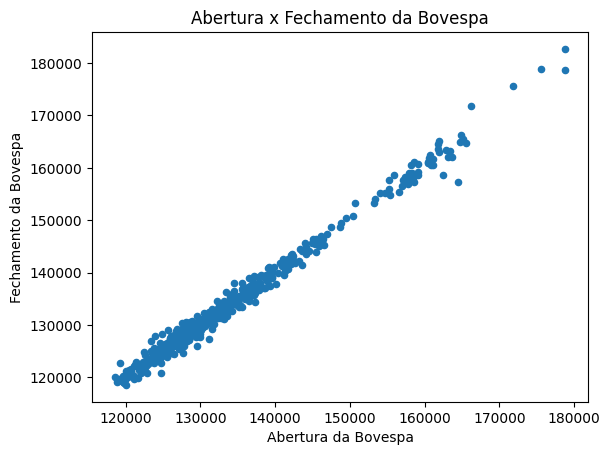

In [ ]:
# Gráfico de disperssão
df_ibov.plot(x="abertura", y="ultimo", kind="scatter")

plt.xlabel("Abertura da Bovespa")
plt.ylabel("Fechamento da Bovespa")
plt.title("Abertura x Fechamento da Bovespa")
plt.show()

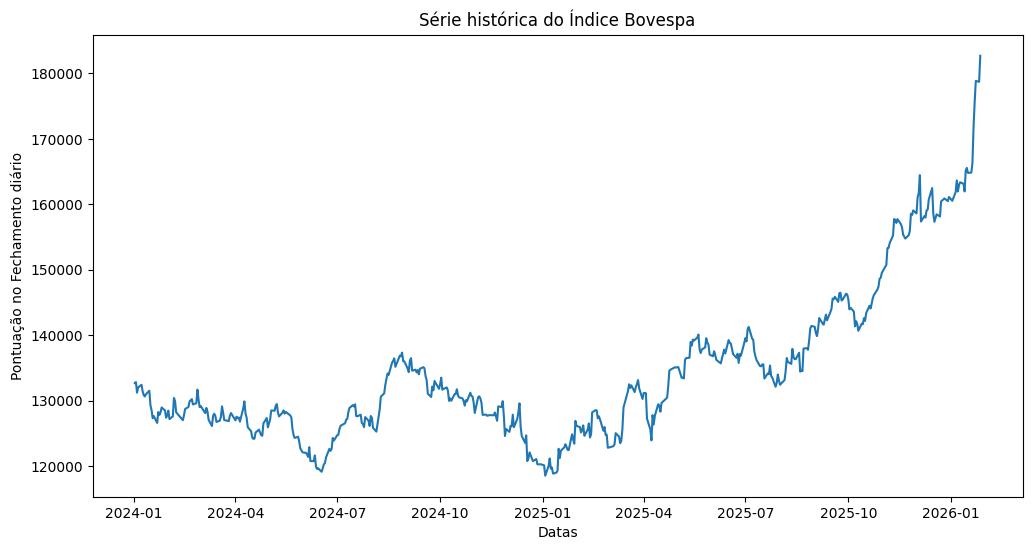

In [ ]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(df_ibov["data"], df_ibov["ultimo"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

/tmp/ipython-input-232/1848606266.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vol_reais', data=df_ibov, palette='hls')


<Axes: xlabel='vol_reais'>

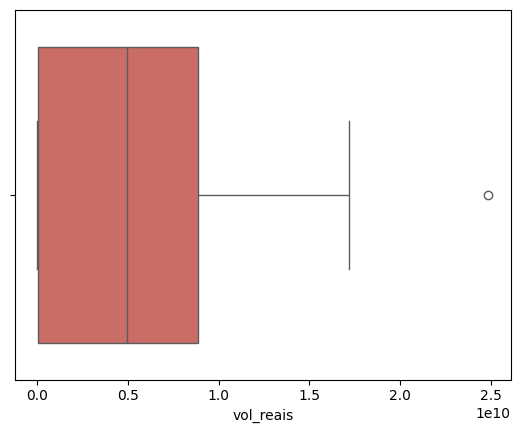

In [ ]:
sns.boxplot(x='vol_reais', data=df_ibov, palette='hls')

<Axes: xlabel='ultimo', ylabel='Count'>

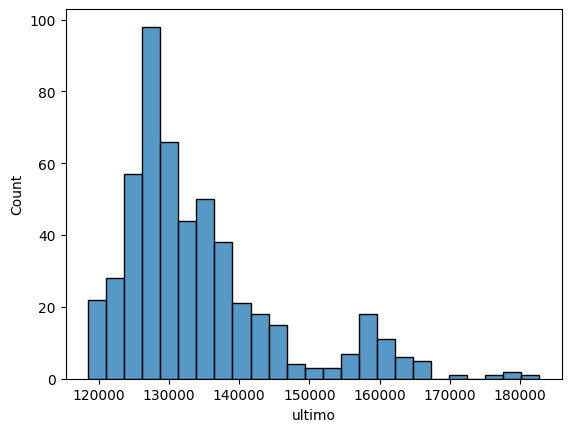

In [ ]:
# Histograma em que podemos ver que da série histórica a maior parte do período o Ibovespa
# ficou em 125k e 140 k pontos
sns.histplot(data=df_ibov, x="ultimo")

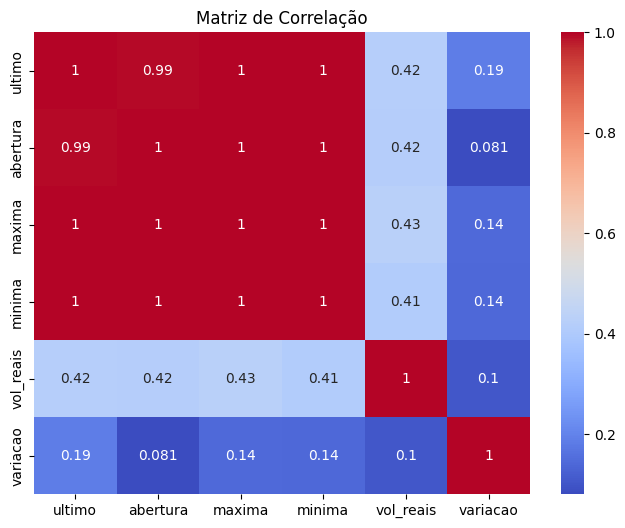

In [ ]:
# correlação entre variáveis (abertura, maxima, minima, volume)
cols_numericas_for_corr = ['ultimo', 'abertura', 'maxima', 'minima', 'vol_reais', 'variacao']

plt.figure(figsize=(8,6))
sns.heatmap(df_ibov[cols_numericas_for_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [ ]:
# treino = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] < '2026-01-07'].dropna()
# valid = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] >= '2026-01-07'].dropna()

# Modelo KNN

In [ ]:
x = df_ibov[['abertura', 'maxima', 'minima', 'ultimo']] # variáveis independentes
y = df_ibov['target'] # variável target é o atributo específico que o modelo e treinado a prever ou classificar)

In [ ]:
from sklearn.model_selection import train_test_split #separação em treino e teste
from sklearn.neighbors import KNeighborsClassifier   #knn

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)

In [ ]:
x_train.shape, x_test.shape

((415, 4), (104, 4))

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler #Feature Engineer

In [ ]:
# É uma técnica de pré-processamento para padronizar features ao remover a média e escalar para a variância unitária, resultando em média 0 e desvio padrão 1
scaler = StandardScaler()
#scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
error = []

# Calculando error for k valeus between 1 and 10
for i in range(1, 11): # quantas tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i) # definição do k
    knn.fit(x_train_scaled, y_train) # trainando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_scaled) # armazenamento das previsões
    error.append(np.mean(pred_i != y_test)) # armazenamento do valor do erro médio na lista de erros

Text(0, 0.5, 'Mean Error')

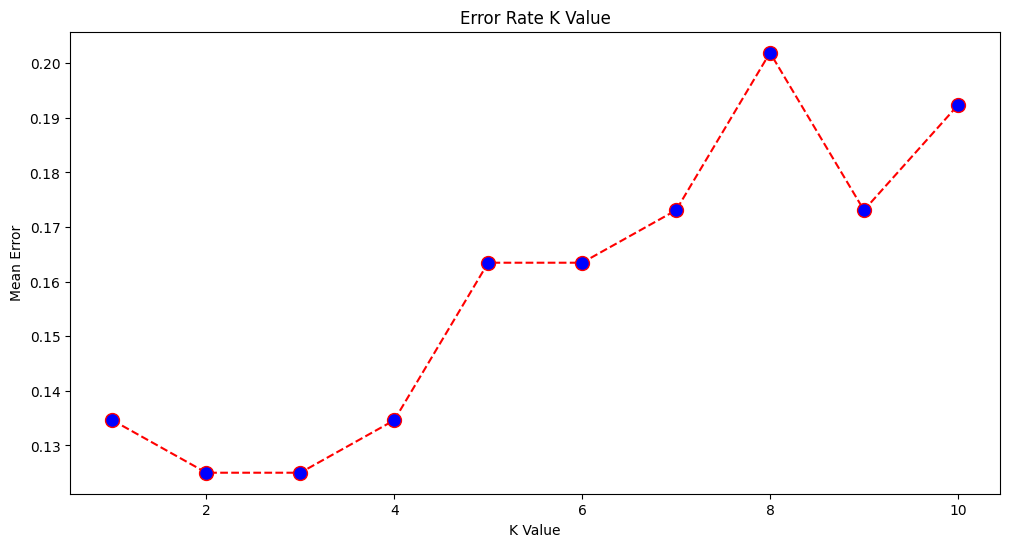

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), error, color = "red", linestyle = "dashed", marker = "o", markerfacecolor = "blue", markersize = 10)
plt.title("Error Rate K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Error")

In [ ]:
# !pip install --upgrade scikit-learn

In [ ]:
# Escolha da quantidades de k que o modelo vai se aproximar.
from sklearn.neighbors import KNeighborsClassifier
modelo_classificador = KNeighborsClassifier(n_neighbors=5)
modelo_classificador.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Um preditor é uma variável, sistema ou pessoa que antecipa, estima ou prevê um resultado futuro com base em dados, características (como idade/sexo) ou sinais (vibração/tensão).
# Utilizados em estatística, aprendizado de máquina e engenharias, ajudam a identificar tendências, riscos ou falhas precoces, otimizando decisões.
y_predito = modelo_classificador.predict(x_test_scaled)

In [ ]:
y_predito

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
# Metricas de precisão, revogação, f1-score e acurária
print(accuracy_score(y_test, y_predito)) # relatório de valiação das métricas de desempenho.

0.8365384615384616


# Modelo SVM

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [ ]:
svm = Pipeline([("liner-svs", LinearSVC(C=1, loss="hinge"))])

svm.fit(x_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('liner-svs', LinearSVC(C=1, loss='hinge'))])

In [ ]:
y_predito_svm = svm.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_predito_svm))

0.9711538461538461


# Árvore de decisão

In [ ]:
# Separando os dados
x_forest = df_ibov.drop(columns=['target', 'data', 'volume', 'var_targ'])
y_forest = df_ibov['target']
#Separando em bases de treino e teste
x_forest_train, x_forest_test, y__forest_train, y__forest_test = train_test_split(x_forest, y_forest, test_size=0.2, stratify=y_forest, random_state=7)

### Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# modelo utilizando todas as variáveis do modelo
d_tree = DecisionTreeClassifier(random_state=42, criterion = 'entropy', max_depth = 2)
d_tree.fit(x_forest_train, y__forest_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

In [ ]:
y_predito_dt = d_tree.predict(x_forest_test)

[Text(0.5, 0.75, 'x[4] <= 0.0\nentropy = 0.998\nsamples = 415\nvalue = [218, 197]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 197\nvalue = [0, 197]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 218\nvalue = [218, 0]'),
 Text(0.625, 0.5, '  False')]

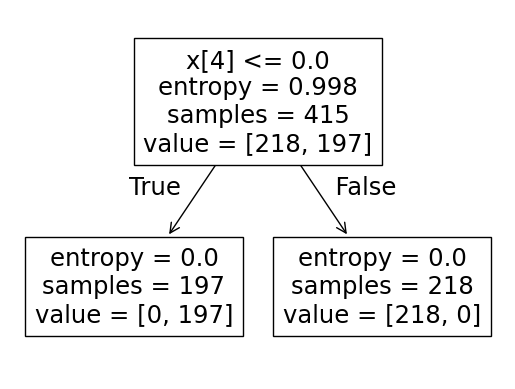

In [ ]:
from sklearn import tree
tree.plot_tree(d_tree)

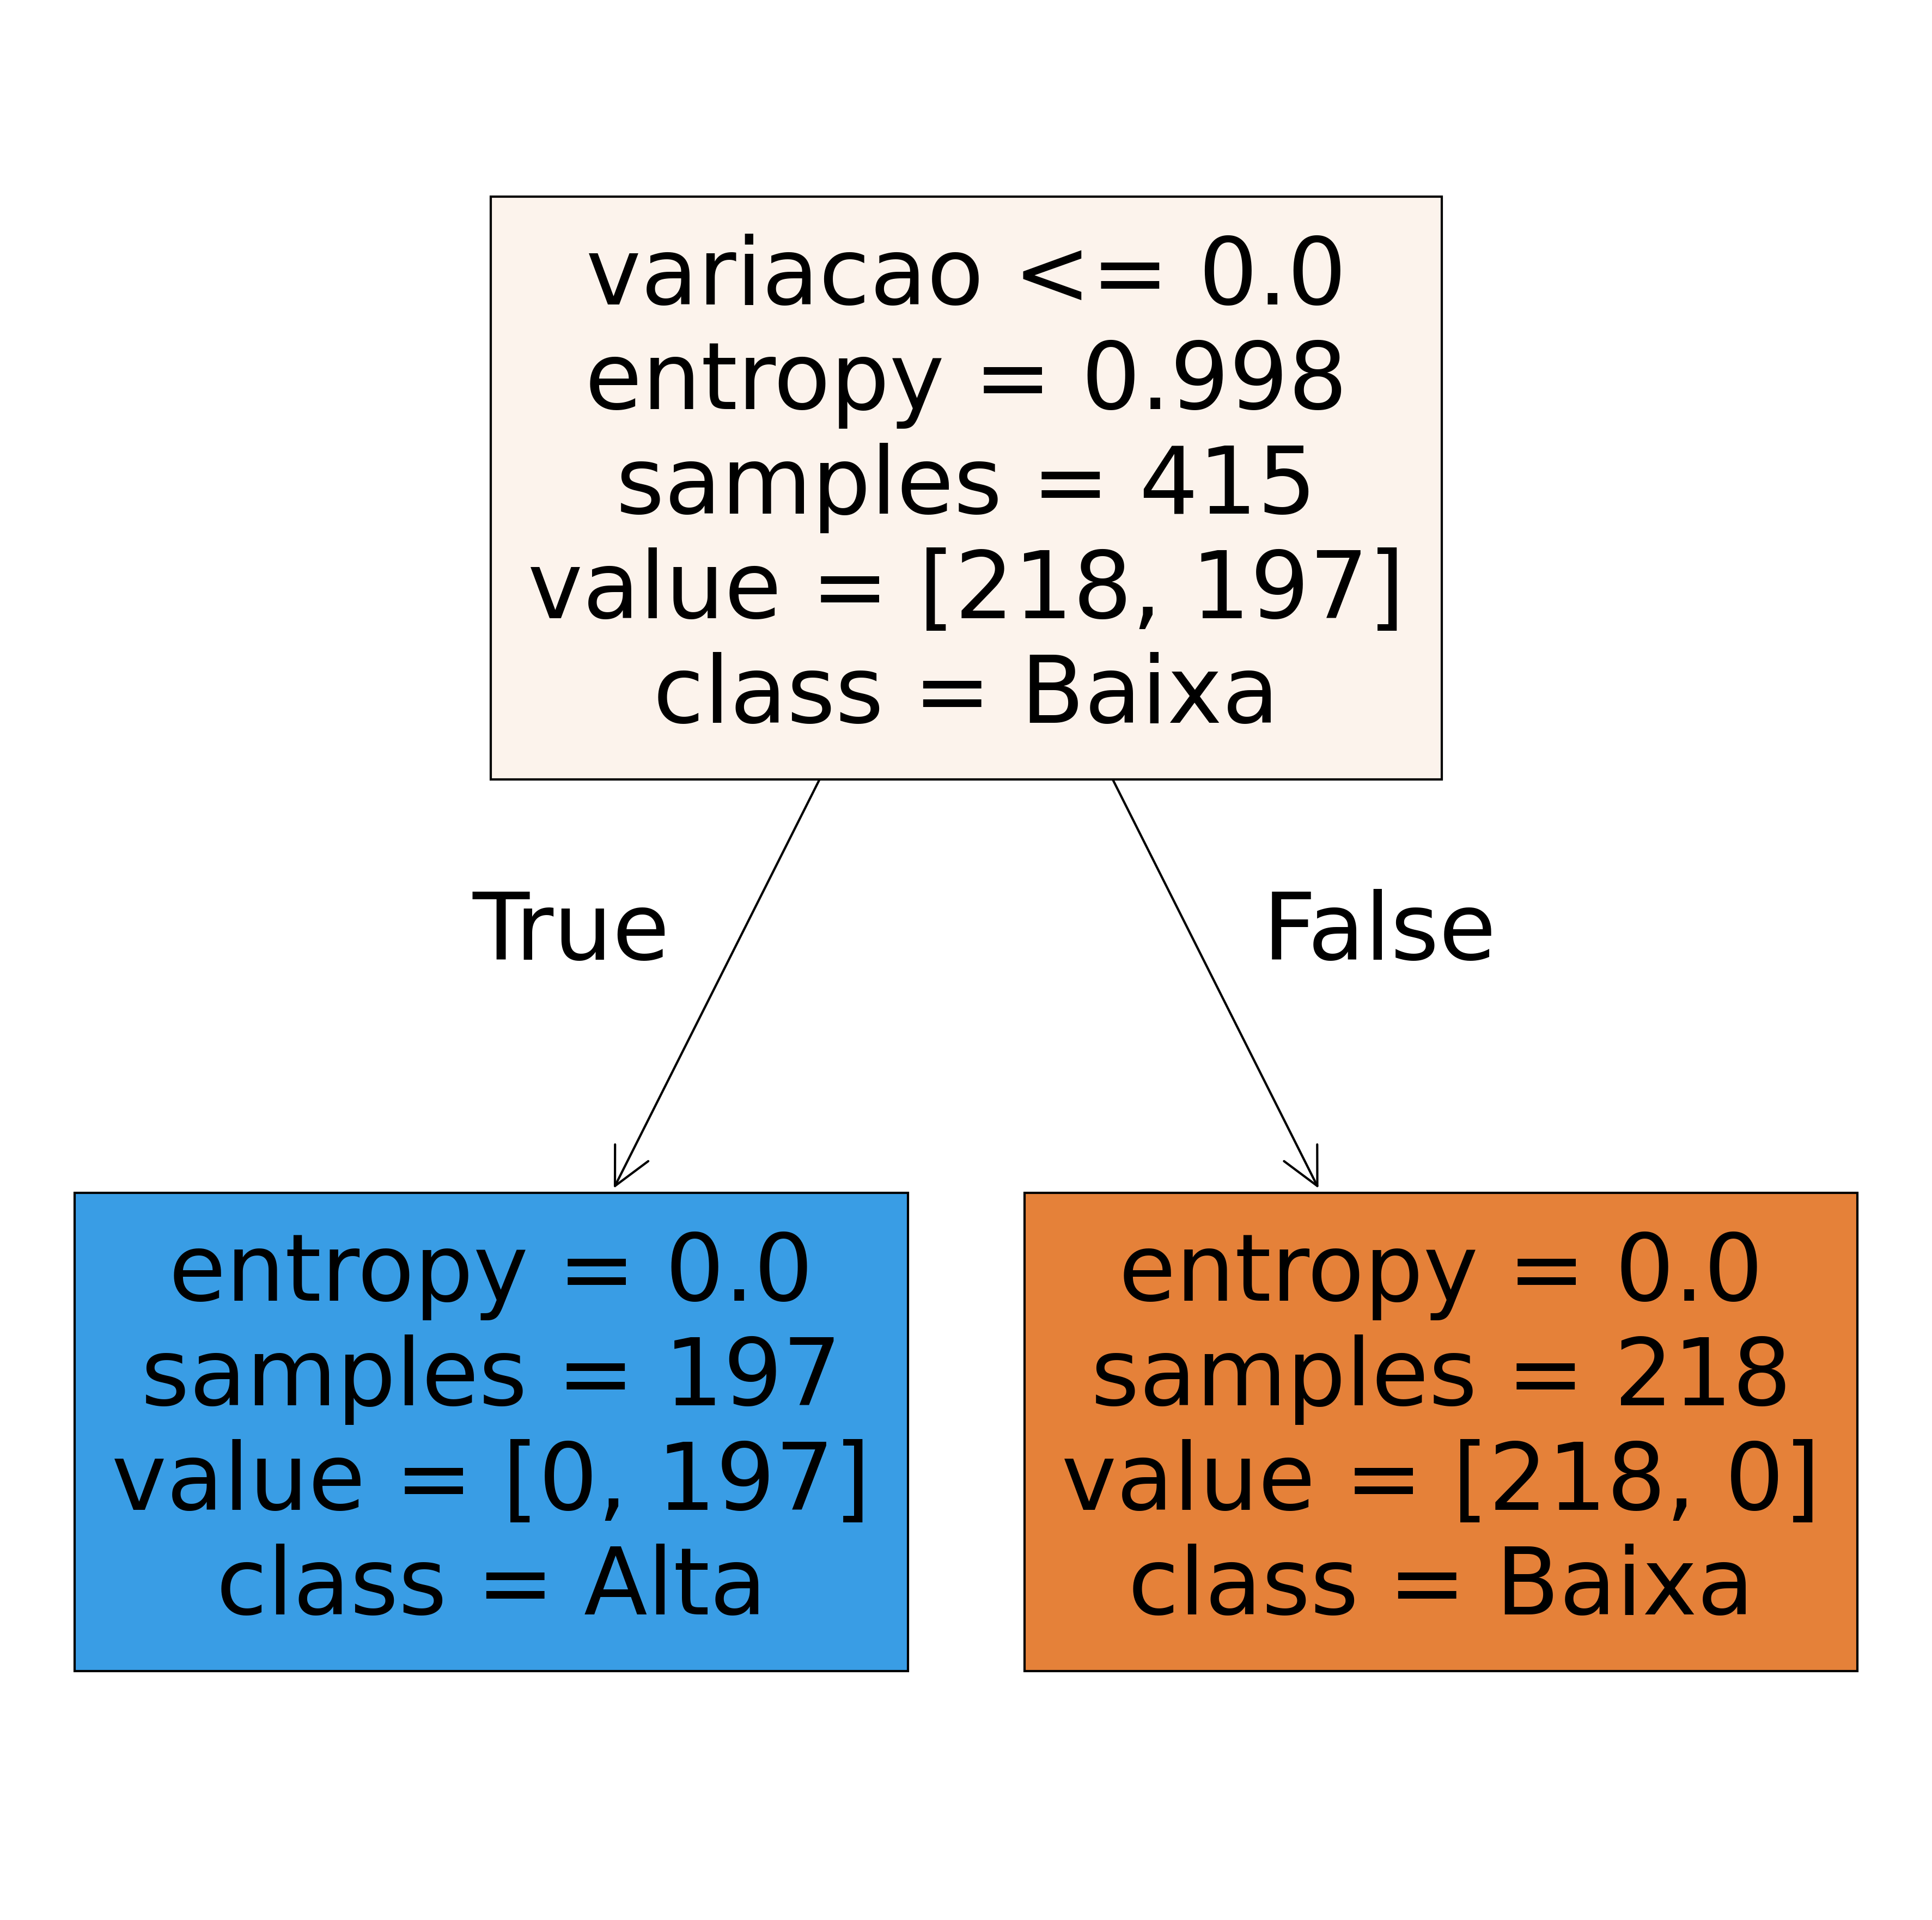

In [ ]:
class_names = ['Baixa', 'Alta']
label_names = ['ultimo',	'abertura',	'maxima',	'minima',	'variacao',	'vol_reais']

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (15,15), dpi=300)

tree.plot_tree(d_tree,
               feature_names = label_names,
               class_names=class_names,
               filled = True)

fig.savefig('imagename.png')

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y__forest_test, y_predito_dt)) #relatório de validação das métrica de desempenho.

1.0


## Definir a relação entre retorno e volatilidade

## 1. Definições
### 1.1 Retorno mede quanto o preço variou de um período para outro.
### 1.2 Volatilidade é risco. Mede o quanto os retornos oscilam. (alta volatilidade → mercado nervoso e baixa volatilidade → mercado estável)


In [ ]:
df_ibov["Retorno_Diario"] = df_ibov["ultimo"].pct_change()
# Distribuição de Retornos
sns.histplot(df_ibov["Retorno_Diario"].dropna(), bins=50, kde=True)
plt.xlabel("Retorno Diário")
plt.ylabel("Frequência")
plt.title("Distribuição dos retornos diários")
plt.show()


In [ ]:
# volatilidade diária média.
vol_diaria = df_ibov["Retorno_Diario"].std()
vol_diaria

In [ ]:
# Volatilidade anualizada
vol_anual = vol_diaria * np.sqrt(252)
vol_anual

In [ ]:
# identificando outliers
sns.boxplot(x=df_ibov["Retorno_Diario"])
plt.title("Outliers nos retornos diários")
plt.xlabel("Retorno Diário")
plt.show()


In [ ]:
# Cálculo e gráfico das médias móveis
df_ibov["MM_20"] = df_ibov["ultimo"].rolling(20).mean()
df_ibov["MM_50"] = df_ibov["ultimo"].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df_ibov["data"], df_ibov["ultimo"], label="Ibovespa", alpha = 0.6)
plt.plot(df_ibov["data"], df_ibov["MM_20"], label="MM 20")
plt.plot(df_ibov["data"], df_ibov["MM_50"], label="MM 50")
plt.legend(loc="upper left")
plt.xlabel("Linha do Tempo")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Ibovespa (2 anos) vs Índice dos 20 e 50 dias")
plt.show()

In [ ]:
# Separação do banco de dados pra Machine Learning
from sklearn.model_selection import train_test_split

In [ ]:
df_ibov.head()